# Assignment 2 GPU Notebook - Multilingual Transformers

This notebook is the compute-heavy companion to `pipeline_final.ipynb`. I reuse the same Gmail ingestion, trigger-based labeling, and thread-aware splitting logic from Assignment 1, but replace the TF-IDF classifiers with multilingual transformer models that can use richer semantics.

The idea is simple: leave this notebook running on a GPU overnight, save checkpoints and evaluation artifacts to disk, and later pull the best model into the polished Assignment 2 report.

This notebook focuses on two multilingual transformer runs:
- `distilbert-base-multilingual-cased` as a lighter baseline
- `xlm-roberta-base` as a stronger multilingual model

Important differences from Assignment 1:
- I keep the same group-aware test split based on `thread_id` for a fair comparison.
- Instead of full GroupKFold CV, I use a group-aware train/validation/test split because end-to-end transformer fine-tuning is much more expensive.
- I train on lightly normalized `subject + body` text rather than TF-IDF-cleaned tokens so the model can use more of the original semantics.

This is an experimental training notebook, not the final PDF report.

In [1]:
from google.colab import drive
from pathlib import Path
import os
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip install -q datasets sentencepiece bs4

In [3]:
import gc
import json
import random
import re
from pathlib import Path

import mailbox
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from bs4 import BeautifulSoup
from datasets import Dataset
from email.header import decode_header
from email.utils import parsedate_to_datetime
from IPython.display import Markdown, display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupShuffleSplit
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT_DIR = Path('./drive/MyDrive/data_cs156')

MBOX_PATHS = [
    str(PROJECT_ROOT_DIR / "Takeout EV/Poczta/Cała poczta, w tym Spam i Kosz.mbox"),
    str(PROJECT_ROOT_DIR / "Takeout MU/Mail/All mail Including Spam and Trash.mbox"),
]

TEXT_COLUMN = "text_transformer"
LABEL_COLUMN = "label"
GROUP_COLUMN = "thread_id"
LABELS = ["needs_reply", "no_reply", "promotional"]
label2id = {label: idx for idx, label in enumerate(LABELS)}
id2label = {idx: label for label, idx in label2id.items()}

BASELINE_RESULTS = {
    "Logistic Regression (A1)": 0.7193,
    "Naive Bayes (A1)": 0.6498,
    "MLP (A1)": 0.6563,
}

MODEL_SPECS = [
    # --- DistilBERT configs ---
    {
        "display_name": "DistilBERT (LR 2e-5, Ep 3)",
        "checkpoint": "distilbert-base-multilingual-cased",
        "max_length": 512,
        "learning_rate": 2e-5,
        "train_batch_size": 64,
        "eval_batch_size": 128,
        "gradient_accumulation_steps": 1,
        "num_train_epochs": 3,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
    },
    {
        "display_name": "DistilBERT (LR 5e-5, Ep 4)",
        "checkpoint": "distilbert-base-multilingual-cased",
        "max_length": 512,
        "learning_rate": 5e-5,
        "train_batch_size": 64,
        "eval_batch_size": 128,
        "gradient_accumulation_steps": 1,
        "num_train_epochs": 4,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
    },
    {
        "display_name": "DistilBERT (LR 3e-5, Ep 5, BS 32)",
        "checkpoint": "distilbert-base-multilingual-cased",
        "max_length": 512,
        "learning_rate": 3e-5,
        "train_batch_size": 64,
        "eval_batch_size": 128,
        "gradient_accumulation_steps": 1,
        "num_train_epochs": 5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
    },
    # --- XLM-R configs ---
    {
        "display_name": "XLM-R base (LR 2e-5, Ep 2)",
        "checkpoint": "xlm-roberta-base",
        "max_length": 512,
        "learning_rate": 2e-5,
        "train_batch_size": 32,
        "eval_batch_size": 64,
        "gradient_accumulation_steps": 1,
        "num_train_epochs": 2,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
    },
    {
        "display_name": "XLM-R base (LR 1e-5, Ep 4)",
        "checkpoint": "xlm-roberta-base",
        "max_length": 512,
        "learning_rate": 1e-5,
        "train_batch_size": 32,
        "eval_batch_size": 64,
        "gradient_accumulation_steps": 1,
        "num_train_epochs": 4,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
    },
    {
        "display_name": "XLM-R base (LR 3e-5, Ep 5, WD 0.1)",
        "checkpoint": "xlm-roberta-base",
        "max_length": 512,
        "learning_rate": 3e-5,
        "train_batch_size": 32,
        "eval_batch_size": 64,
        "gradient_accumulation_steps": 1,
        "num_train_epochs": 5,
        "weight_decay": 0.1,
        "warmup_ratio": 0.1,
    },
    # --- mBERT config ---
    {
        "display_name": "mBERT base (LR 3e-5, Ep 3)",
        "checkpoint": "bert-base-multilingual-cased",
        "max_length": 512,
        "learning_rate": 3e-5,
        "train_batch_size": 32,
        "eval_batch_size": 64,
        "gradient_accumulation_steps": 1,
        "num_train_epochs": 3,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
    },
    # --- max_length sweep on best model ---
    {
        "display_name": "DistilBERT (LR 5e-5, Ep 4, ML 384)",
        "checkpoint": "distilbert-base-multilingual-cased",
        "max_length": 512,
        "learning_rate": 5e-5,
        "train_batch_size": 64,
        "eval_batch_size": 128,
        "gradient_accumulation_steps": 1,
        "num_train_epochs": 4,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
    },
]

OUTPUT_ROOT = Path("artifacts/assignment2_transformers")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Skip slow .mbox parsing on reruns: load pre-built Parquet if present.
PROCESSED_CACHE_PATH = Path("artifacts/cache/transformer_email_dataset.parquet")
PROCESSED_CACHE_META_PATH = Path("artifacts/cache/transformer_email_dataset_meta.json")
USE_PROCESSED_CACHE = True  # set False to force a full re-parse from MBOX_PATHS
PROCESSED_CACHE_VERSION = 1  # bump when ingestion or labeling logic changes

if torch.cuda.is_available():
    print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    print("Using Apple Metal (MPS). The notebook can still run, though CUDA would be faster.")
else:
    print("No GPU backend detected. The notebook will still work, but fine-tuning will be slow on CPU.")

pd.set_option("display.max_colwidth", 120)

Using CUDA GPU: NVIDIA A100-SXM4-40GB


## Reused data pipeline

The next two cells intentionally reuse the same ingestion and label-construction logic from Assignment 1 so the eventual comparison stays fair. I am keeping the Gmail parsing, trigger-based `needs_reply` labeling, automated-sender filtering, and thread-based grouping consistent with the original notebook.

In [4]:
def decode_subject(subject):
    """Decode a MIME-encoded subject line into a plain string."""
    if not subject:
        return ""
    parts = decode_header(subject)
    decoded = []
    for part, enc in parts:
        if isinstance(part, bytes):
            try:
                decoded.append(part.decode(enc or "utf-8", errors="ignore"))
            except (LookupError, TypeError):
                decoded.append(part.decode("latin-1", errors="ignore"))
        else:
            decoded.append(part)
    return "".join(decoded)


def _decode_part(part):
    """Decode a single MIME part payload into a string."""
    raw = part.get_payload(decode=True)
    if not raw:
        return ""
    return raw.decode(part.get_content_charset() or "utf-8", errors="ignore")


def extract_body(msg):
    """Extract visible body text, preferring HTML over plain text."""
    html_part = None
    plain_part = None
    for part in msg.walk():
        ctype = part.get_content_type()
        if ctype == "text/html" and not html_part:
            html_part = part
        elif ctype == "text/plain" and not plain_part:
            plain_part = part

    if html_part:
        try:
            raw_html = _decode_part(html_part)
            soup = BeautifulSoup(raw_html, "html.parser")
            for tag in soup(["style", "script"]):
                tag.decompose()
            text = soup.get_text(separator=" ")
            raw_len = len(raw_html)
            ratio = max(0.0, 1.0 - len(text) / raw_len) if raw_len > 0 else 0.0
            return text, True, ratio
        except Exception:
            pass

    return (_decode_part(plain_part) if plain_part else ""), False, 0.0


def parse_mbox(path):
    """Parse an mbox file into a DataFrame."""
    records = []
    for msg in mailbox.mbox(path):
        try:
            date = parsedate_to_datetime(msg["date"]) if msg["date"] else None
        except Exception:
            date = None

        body_text, html_processed, html_ratio = extract_body(msg)
        records.append(
            {
                "thread_id": str(msg.get("X-GM-THRID", "") or ""),
                "labels": str(msg.get("X-Gmail-Labels", "") or ""),
                "subject": decode_subject(msg.get("subject", "")),
                "from": str(msg.get("from", "") or ""),
                "to": str(msg.get("to", "") or ""),
                "cc": str(msg.get("cc", "") or ""),
                "date": date,
                "body": body_text,
                "has_unsubscribe": "List-Unsubscribe" in msg.keys(),
                "html_processed": html_processed,
                "html_ratio": html_ratio,
            }
        )
    return pd.DataFrame(records)


def decode_label(label):
    """Decode MIME-encoded Gmail label strings."""
    if not label:
        return ""
    try:
        parts = decode_header(label)
        decoded = []
        for part, enc in parts:
            if isinstance(part, bytes):
                try:
                    decoded.append(part.decode(enc or "utf-8", errors="ignore"))
                except (LookupError, TypeError):
                    decoded.append(part.decode("latin-1", errors="ignore"))
            else:
                decoded.append(part)
        return "".join(decoded)
    except Exception:
        return str(label)


In [5]:
PROCESSED_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

_loaded_from_cache = False
if USE_PROCESSED_CACHE and PROCESSED_CACHE_PATH.exists():
    try:
        meta = json.loads(PROCESSED_CACHE_META_PATH.read_text(encoding="utf-8"))
        if meta.get("version") == PROCESSED_CACHE_VERSION:
            df = pd.read_parquet(PROCESSED_CACHE_PATH)
            _loaded_from_cache = True
            display(Markdown(
                f"Loaded **{len(df):,}** rows from cache `{PROCESSED_CACHE_PATH}`. "
                f"Set `USE_PROCESSED_CACHE = False` or bump `PROCESSED_CACHE_VERSION` to rebuild from `.mbox`."
            ))
    except Exception as exc:
        print(f"Cache load failed ({exc}), rebuilding from mbox...")

if not _loaded_from_cache:
    dfs = [parse_mbox(path) for path in MBOX_PATHS]
    df_raw = pd.concat(dfs, ignore_index=True)
    df_raw["labels_decoded"] = df_raw["labels"].apply(decode_label)
    display(Markdown(f"Parsed **{len(df_raw):,}** raw messages from **{len(MBOX_PATHS)}** Gmail exports."))

    df_raw["date_utc"] = pd.to_datetime(df_raw["date"], utc=True, errors="coerce")
    df_raw_sorted = df_raw.sort_values("date_utc").reset_index(drop=True)

    sent_mask = df_raw_sorted["labels_decoded"].str.contains("Sent|Wysłano", na=False)
    sent_emails = df_raw_sorted[sent_mask]

    AUTO_SENDER_PATTERNS = [
        "noreply", "no-reply", "no_reply",
        "mailer-daemon", "postmaster",
        "donotreply", "do-not-reply", "do_not_reply",
        "notifications@", "notification@",
        "reminders@", "reminder@",
        "calendar-notification",
        "forms-receipts-noreply",
        "bounce",
    ]

    def is_automated_sender(from_addr):
        if not isinstance(from_addr, str):
            return False
        lower = from_addr.lower()
        return any(pattern in lower for pattern in AUTO_SENDER_PATTERNS)

    auto_mask = df_raw_sorted["from"].apply(is_automated_sender) | df_raw_sorted["has_unsubscribe"]

    reply_trigger_indices = set()
    for _, sent in sent_emails.iterrows():
        if pd.isna(sent["date_utc"]):
            continue
        candidates = df_raw_sorted[
            (df_raw_sorted["thread_id"] == sent["thread_id"])
            & (~sent_mask)
            & (~auto_mask)
            & (df_raw_sorted["date_utc"].notna())
            & (df_raw_sorted["date_utc"] < sent["date_utc"])
        ]
        if len(candidates) > 0:
            reply_trigger_indices.add(candidates.index[-1])

    def assign_label(row):
        labels = row["labels_decoded"]
        if "Spam" in labels:
            return "spam"
        if "Category Promotions" in labels or "Kategoria: promocje" in labels:
            return "promotional"
        if "Sent" in labels or "Wysłano" in labels:
            return None
        if row.name in reply_trigger_indices:
            return "needs_reply"
        return "no_reply"

    def normalize_for_transformer(text):
        if not isinstance(text, str):
            return ""
        text = text.replace("\xa0", " ")
        text = re.sub(r"\s+", " ", text).strip()
        return text

    df_raw_sorted[LABEL_COLUMN] = df_raw_sorted.apply(assign_label, axis=1)

    df = df_raw_sorted[df_raw_sorted[LABEL_COLUMN].notna()].copy()
    df = df[df["body"].str.len() > 20].copy()
    df = df[df[LABEL_COLUMN] != "spam"].copy()

    df["subject_norm"] = df["subject"].fillna("").apply(normalize_for_transformer)
    df["body_norm"] = df["body"].fillna("").apply(normalize_for_transformer)
    df[TEXT_COLUMN] = "subject: " + df["subject_norm"] + "\nbody: " + df["body_norm"]

    df.to_parquet(PROCESSED_CACHE_PATH, index=False)
    PROCESSED_CACHE_META_PATH.write_text(
        json.dumps(
            {"version": PROCESSED_CACHE_VERSION, "n_rows": len(df), "columns": list(df.columns)},
            indent=2,
        ),
        encoding="utf-8",
    )
    display(Markdown(f"Saved processed dataset to `{PROCESSED_CACHE_PATH}` for faster reruns."))

display(Markdown(f"Final transformer dataset: **{len(df):,}** incoming emails."))
class_counts = df[LABEL_COLUMN].value_counts().reindex(LABELS)
class_summary = pd.DataFrame({
    "count": class_counts,
    "share %": (class_counts / class_counts.sum() * 100).round(2),
})
display(class_summary)

Parsed **36,276** raw messages from **2** Gmail exports.

Saved processed dataset to `artifacts/cache/transformer_email_dataset.parquet` for faster reruns.

Final transformer dataset: **32,783** incoming emails.

,count,share %
label,,
needs_reply,1536,4.69
no_reply,24770,75.56
promotional,6477,19.76


## Group-aware split

To stay comparable with Assignment 1, I keep the same outer `thread_id`-aware split for the held-out test set. Inside the training portion I create one additional group-aware validation split. This is the compromise that makes transformer training feasible while still avoiding thread leakage.

In [6]:
X_text = df[TEXT_COLUMN].values
y = df[LABEL_COLUMN].values
groups = df[GROUP_COLUMN].values

outer_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_full, idx_test = next(outer_gss.split(X_text, y, groups=groups))

inner_gss = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=SEED)
rel_train_idx, rel_val_idx = next(
    inner_gss.split(X_text[idx_train_full], y[idx_train_full], groups=groups[idx_train_full])
)

idx_train = idx_train_full[rel_train_idx]
idx_val = idx_train_full[rel_val_idx]

df_train = df.iloc[idx_train].copy()
df_val = df.iloc[idx_val].copy()
df_test = df.iloc[idx_test].copy()


def build_dataset(frame):
    return Dataset.from_pandas(
        pd.DataFrame(
            {
                "text": frame[TEXT_COLUMN].tolist(),
                "labels": frame[LABEL_COLUMN].map(label2id).astype(int).tolist(),
                "thread_id": frame[GROUP_COLUMN].astype(str).tolist(),
                "subject": frame["subject_norm"].tolist(),
            }
        ),
        preserve_index=False,
    )


train_ds = build_dataset(df_train)
val_ds = build_dataset(df_val)
test_ds = build_dataset(df_test)

display(Markdown(
    f"Split sizes: **train {len(df_train):,}**, **val {len(df_val):,}**, **test {len(df_test):,}**"
))

split_summary = pd.DataFrame(
    {
        "Train": df_train[LABEL_COLUMN].value_counts(),
        "Val": df_val[LABEL_COLUMN].value_counts(),
        "Test": df_test[LABEL_COLUMN].value_counts(),
    }
).fillna(0).astype(int).reindex(LABELS)
for col in ["Train", "Val", "Test"]:
    split_summary[f"{col} %"] = (split_summary[col] / split_summary[col].sum() * 100).round(2)
display(split_summary)

print(
    "Thread overlaps (train/val, train/test, val/test):",
    len(set(df_train[GROUP_COLUMN]) & set(df_val[GROUP_COLUMN])),
    len(set(df_train[GROUP_COLUMN]) & set(df_test[GROUP_COLUMN])),
    len(set(df_val[GROUP_COLUMN]) & set(df_test[GROUP_COLUMN])),
)

train_class_counts = df_train[LABEL_COLUMN].value_counts().reindex(LABELS)
class_weights = torch.tensor(
    len(df_train) / (len(LABELS) * train_class_counts.values),
    dtype=torch.float,
)
display(pd.DataFrame({
    "train_count": train_class_counts,
    "class_weight": class_weights.numpy().round(4),
}, index=LABELS))

Split sizes: **train 22,977**, **val 3,228**, **test 6,578**

,Train,Val,Test,Train %,Val %,Test %
label,,,,,,
needs_reply,1094,136,306,4.76,4.21,4.65
no_reply,17385,2468,4917,75.66,76.46,74.75
promotional,4498,624,1355,19.58,19.33,20.60


Thread overlaps (train/val, train/test, val/test): 0 0 0


,train_count,class_weight
needs_reply,1094,7.0009
no_reply,17385,0.4406
promotional,4498,1.7028


## Training utilities

The helper code below handles tokenization, weighted loss, metrics, and artifact saving. I use a weighted cross-entropy loss because `needs_reply` is still the smallest class, and macro F1 remains the main metric so the rare class matters during model selection.

In [7]:
def slugify(text):
    return re.sub(r"[^a-z0-9]+", "-", text.lower()).strip("-")


def tokenize_split(dataset, tokenizer, max_length):
    encoded = dataset.map(
        lambda batch: tokenizer(batch["text"], truncation=True, max_length=max_length),
        batched=True,
    )
    keep_cols = {"input_ids", "attention_mask", "token_type_ids", "labels"}
    drop_cols = [col for col in encoded.column_names if col not in keep_cols]
    if drop_cols:
        encoded = encoded.remove_columns(drop_cols)
    return encoded


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, support = precision_recall_fscore_support(
        labels,
        preds,
        labels=list(range(len(LABELS))),
        zero_division=0,
    )
    metrics = {
        "accuracy": float((preds == labels).mean()),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "weighted_f1": f1_score(labels, preds, average="weighted", zero_division=0),
    }
    for idx, label in id2label.items():
        metrics[f"precision_{label}"] = float(precision[idx])
        metrics[f"recall_{label}"] = float(recall[idx])
        metrics[f"f1_{label}"] = float(f1[idx])
        metrics[f"support_{label}"] = int(support[idx])
    return metrics


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weight = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss_fct = torch.nn.CrossEntropyLoss(weight=weight)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


def save_json(payload, path):
    with open(path, "w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2, ensure_ascii=False)


run_summaries = []


=== DistilBERT (LR 2e-5, Ep 3) ===
checkpoint: distilbert-base-multilingual-cased


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## DistilBERT (LR 2e-5, Ep 3)

,0
eval_loss,0.3653
eval_accuracy,0.8405
eval_macro_f1,0.7274
eval_weighted_f1,0.8561
eval_precision_needs_reply,0.3315
eval_recall_needs_reply,0.8824
eval_f1_needs_reply,0.4819
eval_support_needs_reply,136.0000
eval_precision_no_reply,0.9608
eval_recall_no_reply,0.8250


,precision,recall,f1-score,support
needs_reply,0.3592,0.8333,0.5020,306.0000
no_reply,0.9565,0.8324,0.8902,4917.0000
promotional,0.7678,0.9004,0.8288,1355.0000
accuracy,0.8465,0.8465,0.8465,0.8465
macro avg,0.6945,0.8554,0.7403,6578.0000
weighted avg,0.8899,0.8465,0.8595,6578.0000


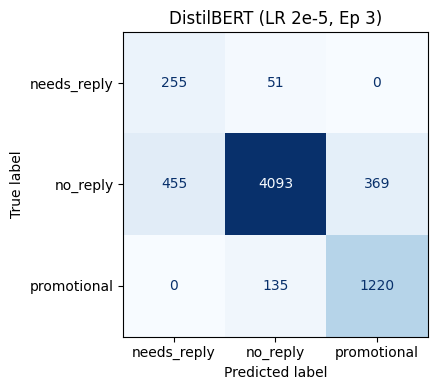


=== DistilBERT (LR 5e-5, Ep 4) ===
checkpoint: distilbert-base-multilingual-cased


Map:   0%|          | 0/22977 [00:00<?, ? examples/s]

Map:   0%|          | 0/3228 [00:00<?, ? examples/s]

Map:   0%|          | 0/6578 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## DistilBERT (LR 5e-5, Ep 4)

,0
eval_loss,0.4774
eval_accuracy,0.8628
eval_macro_f1,0.7462
eval_weighted_f1,0.8733
eval_precision_needs_reply,0.3733
eval_recall_needs_reply,0.8015
eval_f1_needs_reply,0.5093
eval_support_needs_reply,136.0000
eval_precision_no_reply,0.9518
eval_recall_no_reply,0.8643


,precision,recall,f1-score,support
needs_reply,0.3873,0.7190,0.5034,306.0000
no_reply,0.9454,0.8737,0.9081,4917.0000
promotional,0.8138,0.8804,0.8458,1355.0000
accuracy,0.8679,0.8679,0.8679,0.8679
macro avg,0.7155,0.8244,0.7525,6578.0000
weighted avg,0.8923,0.8679,0.8765,6578.0000


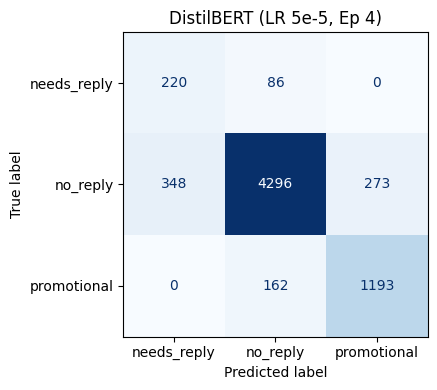


=== DistilBERT (LR 3e-5, Ep 5, BS 32) ===
checkpoint: distilbert-base-multilingual-cased


Map:   0%|          | 0/22977 [00:00<?, ? examples/s]

Map:   0%|          | 0/3228 [00:00<?, ? examples/s]

Map:   0%|          | 0/6578 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## DistilBERT (LR 3e-5, Ep 5, BS 32)

,0
eval_loss,0.5233
eval_accuracy,0.8649
eval_macro_f1,0.7419
eval_weighted_f1,0.8735
eval_precision_needs_reply,0.3828
eval_recall_needs_reply,0.7206
eval_f1_needs_reply,0.5000
eval_support_needs_reply,136.0000
eval_precision_no_reply,0.9456
eval_recall_no_reply,0.8736


,precision,recall,f1-score,support
needs_reply,0.4269,0.7157,0.5348,306.0000
no_reply,0.9443,0.8855,0.9139,4917.0000
promotional,0.8150,0.8745,0.8437,1355.0000
accuracy,0.8753,0.8753,0.8753,0.8753
macro avg,0.7287,0.8252,0.7642,6578.0000
weighted avg,0.8936,0.8753,0.8818,6578.0000


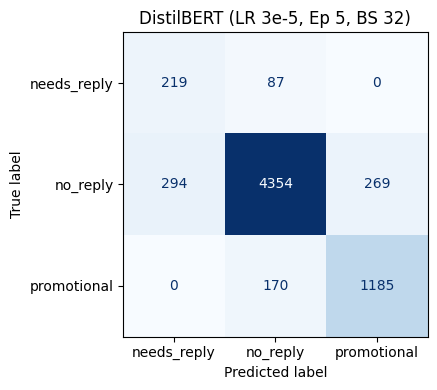


=== XLM-R base (LR 2e-5, Ep 2) ===
checkpoint: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## XLM-R base (LR 2e-5, Ep 2)

,0
eval_loss,0.3944
eval_accuracy,0.8243
eval_macro_f1,0.7137
eval_weighted_f1,0.8412
eval_precision_needs_reply,0.3270
eval_recall_needs_reply,0.8897
eval_f1_needs_reply,0.4783
eval_support_needs_reply,136.0000
eval_precision_no_reply,0.9634
eval_recall_no_reply,0.8006


,precision,recall,f1-score,support
needs_reply,0.3483,0.8627,0.4962,306.0000
no_reply,0.9639,0.8103,0.8804,4917.0000
promotional,0.7398,0.9210,0.8205,1355.0000
accuracy,0.8355,0.8355,0.8355,0.8355
macro avg,0.6840,0.8647,0.7324,6578.0000
weighted avg,0.8891,0.8355,0.8502,6578.0000


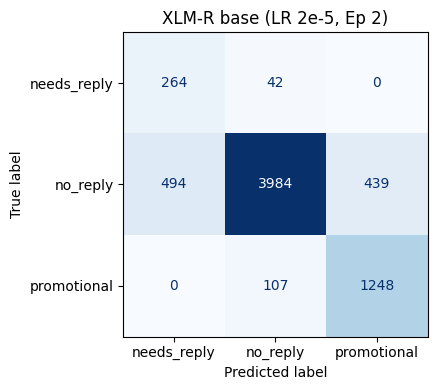


=== XLM-R base (LR 1e-5, Ep 4) ===
checkpoint: xlm-roberta-base


Map:   0%|          | 0/22977 [00:00<?, ? examples/s]

Map:   0%|          | 0/3228 [00:00<?, ? examples/s]

Map:   0%|          | 0/6578 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## XLM-R base (LR 1e-5, Ep 4)

,0
eval_loss,0.4134
eval_accuracy,0.8426
eval_macro_f1,0.7287
eval_weighted_f1,0.8577
eval_precision_needs_reply,0.3343
eval_recall_needs_reply,0.8676
eval_f1_needs_reply,0.4826
eval_support_needs_reply,136.0000
eval_precision_no_reply,0.9605
eval_recall_no_reply,0.8282


,precision,recall,f1-score,support
needs_reply,0.3701,0.8105,0.5082,306.0000
no_reply,0.9569,0.8438,0.8968,4917.0000
promotional,0.7799,0.9048,0.8377,1355.0000
accuracy,0.8548,0.8548,0.8548,0.8548
macro avg,0.7023,0.8530,0.7476,6578.0000
weighted avg,0.8931,0.8548,0.8665,6578.0000


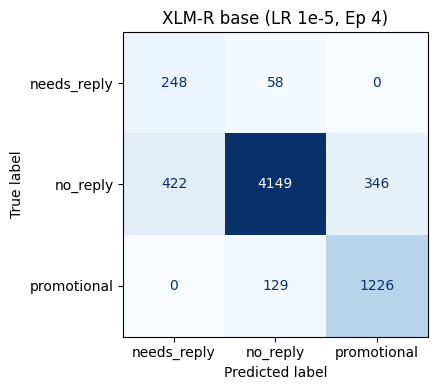


=== XLM-R base (LR 3e-5, Ep 5, WD 0.1) ===
checkpoint: xlm-roberta-base


Map:   0%|          | 0/22977 [00:00<?, ? examples/s]

Map:   0%|          | 0/3228 [00:00<?, ? examples/s]

Map:   0%|          | 0/6578 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## XLM-R base (LR 3e-5, Ep 5, WD 0.1)

,0
eval_loss,0.5749
eval_accuracy,0.8659
eval_macro_f1,0.7442
eval_weighted_f1,0.8744
eval_precision_needs_reply,0.3867
eval_recall_needs_reply,0.7279
eval_f1_needs_reply,0.5051
eval_support_needs_reply,136.0000
eval_precision_no_reply,0.9469
eval_recall_no_reply,0.8736


,precision,recall,f1-score,support
needs_reply,0.4020,0.6634,0.5006,306.000
no_reply,0.9428,0.8853,0.9132,4917.000
promotional,0.8194,0.8804,0.8488,1355.000
accuracy,0.8740,0.8740,0.8740,0.874
macro avg,0.7214,0.8097,0.7542,6578.000
weighted avg,0.8922,0.8740,0.8807,6578.000


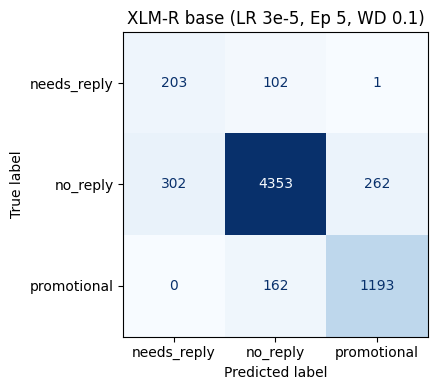


=== mBERT base (LR 3e-5, Ep 3) ===
checkpoint: bert-base-multilingual-cased


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## mBERT base (LR 3e-5, Ep 3)

,0
eval_loss,0.4522
eval_accuracy,0.8575
eval_macro_f1,0.7379
eval_weighted_f1,0.8682
eval_precision_needs_reply,0.3662
eval_recall_needs_reply,0.7647
eval_f1_needs_reply,0.4952
eval_support_needs_reply,136.0000
eval_precision_no_reply,0.9531
eval_recall_no_reply,0.8558


,precision,recall,f1-score,support
needs_reply,0.3848,0.6928,0.4947,306.0000
no_reply,0.9490,0.8670,0.9062,4917.0000
promotional,0.7948,0.9004,0.8443,1355.0000
accuracy,0.8658,0.8658,0.8658,0.8658
macro avg,0.7095,0.8201,0.7484,6578.0000
weighted avg,0.8910,0.8658,0.8743,6578.0000


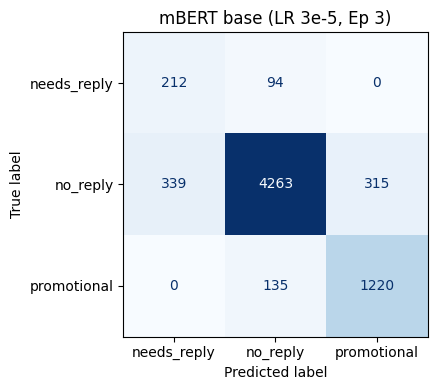


=== DistilBERT (LR 5e-5, Ep 4, ML 384) ===
checkpoint: distilbert-base-multilingual-cased


Map:   0%|          | 0/22977 [00:00<?, ? examples/s]

Map:   0%|          | 0/3228 [00:00<?, ? examples/s]

Map:   0%|          | 0/6578 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## DistilBERT (LR 5e-5, Ep 4, ML 384)

,0
eval_loss,0.4884
eval_accuracy,0.8625
eval_macro_f1,0.7432
eval_weighted_f1,0.8728
eval_precision_needs_reply,0.3693
eval_recall_needs_reply,0.7794
eval_f1_needs_reply,0.5012
eval_support_needs_reply,136.0000
eval_precision_no_reply,0.9494
eval_recall_no_reply,0.8663


,precision,recall,f1-score,support
needs_reply,0.4119,0.7255,0.5254,306.0000
no_reply,0.9474,0.8794,0.9121,4917.0000
promotional,0.8129,0.8849,0.8473,1355.0000
accuracy,0.8734,0.8734,0.8734,0.8734
macro avg,0.7241,0.8299,0.7616,6578.0000
weighted avg,0.8948,0.8734,0.8808,6578.0000


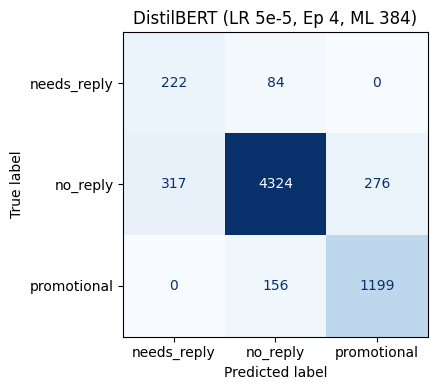

In [8]:
for spec in MODEL_SPECS:
    slug = slugify(spec["display_name"])
    run_dir = OUTPUT_ROOT / slug
    best_dir = run_dir / "best_model"
    run_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n=== {spec['display_name']} ===")
    print(f"checkpoint: {spec['checkpoint']}")

    tokenizer = AutoTokenizer.from_pretrained(spec["checkpoint"], use_fast=True)
    encoded_train = tokenize_split(train_ds, tokenizer, spec["max_length"])
    encoded_val = tokenize_split(val_ds, tokenizer, spec["max_length"])
    encoded_test = tokenize_split(test_ds, tokenizer, spec["max_length"])

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    model = AutoModelForSequenceClassification.from_pretrained(
        spec["checkpoint"],
        num_labels=len(LABELS),
        label2id=label2id,
        id2label=id2label,
    )
    if model.config.pad_token_id is None and tokenizer.pad_token_id is not None:
        model.config.pad_token_id = tokenizer.pad_token_id

    training_args = TrainingArguments(
        output_dir=str(run_dir),
        learning_rate=spec["learning_rate"],
        per_device_train_batch_size=spec["train_batch_size"],
        per_device_eval_batch_size=spec["eval_batch_size"],
        gradient_accumulation_steps=spec["gradient_accumulation_steps"],
        num_train_epochs=spec["num_train_epochs"],
        weight_decay=spec["weight_decay"],
        warmup_ratio=spec["warmup_ratio"],
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="eval_macro_f1",
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
        fp16=torch.cuda.is_available(),
        dataloader_num_workers=0,
        remove_unused_columns=True,
    )

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=encoded_train,
        eval_dataset=encoded_val,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    val_metrics = trainer.evaluate(encoded_val)
    test_metrics = trainer.evaluate(encoded_test, metric_key_prefix="test")
    predictions = trainer.predict(encoded_test)

    pred_ids = np.argmax(predictions.predictions, axis=-1)
    true_ids = predictions.label_ids

    report_df = pd.DataFrame(
        classification_report(
            true_ids,
            pred_ids,
            labels=list(range(len(LABELS))),
            target_names=LABELS,
            output_dict=True,
            zero_division=0,
        )
    ).T.round(4)

    pred_frame = df_test[[GROUP_COLUMN, "subject"]].copy().reset_index().rename(
        columns={"index": "row_index", "subject": "subject_raw"}
    )
    pred_frame["true_label"] = [id2label[int(idx)] for idx in true_ids]
    pred_frame["pred_label"] = [id2label[int(idx)] for idx in pred_ids]

    trainer.save_model(str(best_dir))
    tokenizer.save_pretrained(str(best_dir))
    report_df.to_csv(run_dir / "classification_report.csv")
    pred_frame.to_csv(run_dir / "test_predictions.csv", index=False)
    save_json({**val_metrics, **test_metrics}, run_dir / "metrics.json")

    display(Markdown(f"## {spec['display_name']}"))
    display(pd.DataFrame([{**val_metrics, **test_metrics}]).T.round(4))
    display(report_df)

    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(true_ids, pred_ids, labels=list(range(len(LABELS))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(spec["display_name"])
    plt.tight_layout()
    plt.show()

    run_summaries.append(
        {
            "model": spec["display_name"],
            "checkpoint": spec["checkpoint"],
            "val_macro_f1": val_metrics["eval_macro_f1"],
            "test_macro_f1": test_metrics["test_macro_f1"],
            "test_weighted_f1": test_metrics["test_weighted_f1"],
            "test_accuracy": test_metrics["test_accuracy"],
            "test_f1_needs_reply": test_metrics["test_f1_needs_reply"],
            "test_recall_needs_reply": test_metrics["test_recall_needs_reply"],
            "output_dir": str(run_dir),
        }
    )

    del trainer, model, tokenizer, encoded_train, encoded_val, encoded_test, predictions
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Overnight run summary

,model,checkpoint,val_macro_f1,test_macro_f1,test_weighted_f1,test_accuracy,test_f1_needs_reply,test_recall_needs_reply,output_dir
0,"DistilBERT (LR 3e-5, Ep 5, BS 32)",distilbert-base-multilingual-cased,0.7419,0.7642,0.8818,0.8753,0.5348,0.7157,artifacts/assignment2_transformers/distilbert-lr-3e-5-ep-5-bs-32
1,"DistilBERT (LR 5e-5, Ep 4, ML 384)",distilbert-base-multilingual-cased,0.7432,0.7616,0.8808,0.8734,0.5254,0.7255,artifacts/assignment2_transformers/distilbert-lr-5e-5-ep-4-ml-384
2,"XLM-R base (LR 3e-5, Ep 5, WD 0.1)",xlm-roberta-base,0.7442,0.7542,0.8807,0.8740,0.5006,0.6634,artifacts/assignment2_transformers/xlm-r-base-lr-3e-5-ep-5-wd-0-1
3,"DistilBERT (LR 5e-5, Ep 4)",distilbert-base-multilingual-cased,0.7462,0.7525,0.8765,0.8679,0.5034,0.7190,artifacts/assignment2_transformers/distilbert-lr-5e-5-ep-4
4,"mBERT base (LR 3e-5, Ep 3)",bert-base-multilingual-cased,0.7379,0.7484,0.8743,0.8658,0.4947,0.6928,artifacts/assignment2_transformers/mbert-base-lr-3e-5-ep-3
5,"XLM-R base (LR 1e-5, Ep 4)",xlm-roberta-base,0.7287,0.7476,0.8665,0.8548,0.5082,0.8105,artifacts/assignment2_transformers/xlm-r-base-lr-1e-5-ep-4
6,"DistilBERT (LR 2e-5, Ep 3)",distilbert-base-multilingual-cased,0.7274,0.7403,0.8595,0.8465,0.5020,0.8333,artifacts/assignment2_transformers/distilbert-lr-2e-5-ep-3
7,"XLM-R base (LR 2e-5, Ep 2)",xlm-roberta-base,0.7137,0.7324,0.8502,0.8355,0.4962,0.8627,artifacts/assignment2_transformers/xlm-r-base-lr-2e-5-ep-2


## Assignment 1 vs transformer comparison

,model,macro_f1,family
0,Logistic Regression (A1),0.7193,Assignment 1 baseline
1,Naive Bayes (A1),0.6498,Assignment 1 baseline
2,MLP (A1),0.6563,Assignment 1 baseline
3,"DistilBERT (LR 3e-5, Ep 5, BS 32)",0.7642,Assignment 2 transformer
4,"DistilBERT (LR 5e-5, Ep 4, ML 384)",0.7616,Assignment 2 transformer
5,"XLM-R base (LR 3e-5, Ep 5, WD 0.1)",0.7542,Assignment 2 transformer
6,"DistilBERT (LR 5e-5, Ep 4)",0.7525,Assignment 2 transformer
7,"mBERT base (LR 3e-5, Ep 3)",0.7484,Assignment 2 transformer
8,"XLM-R base (LR 1e-5, Ep 4)",0.7476,Assignment 2 transformer
9,"DistilBERT (LR 2e-5, Ep 3)",0.7403,Assignment 2 transformer


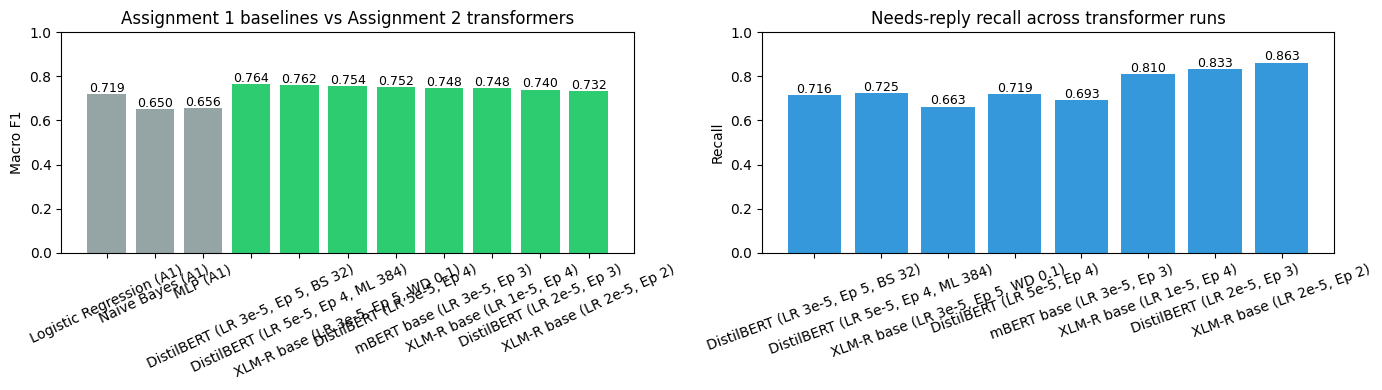

In [9]:
results_df = pd.DataFrame(run_summaries).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
results_df.to_csv(OUTPUT_ROOT / "transformer_summary.csv", index=False)

baseline_df = pd.DataFrame(
    {
        "model": list(BASELINE_RESULTS.keys()),
        "macro_f1": list(BASELINE_RESULTS.values()),
        "family": "Assignment 1 baseline",
    }
)
transformer_df = results_df[["model", "test_macro_f1"]].rename(columns={"test_macro_f1": "macro_f1"})
transformer_df["family"] = "Assignment 2 transformer"
comparison_df = pd.concat([baseline_df, transformer_df], ignore_index=True)
comparison_df.to_csv(OUTPUT_ROOT / "baseline_vs_transformers.csv", index=False)

display(Markdown("## Overnight run summary"))
display(results_df.round(4))
display(Markdown("## Assignment 1 vs transformer comparison"))
display(comparison_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ["#95a5a6" if fam == "Assignment 1 baseline" else "#2ecc71" for fam in comparison_df["family"]]
axes[0].bar(comparison_df["model"], comparison_df["macro_f1"], color=colors)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Macro F1")
axes[0].set_title("Assignment 1 baselines vs Assignment 2 transformers")
axes[0].tick_params(axis="x", rotation=25)
for i, score in enumerate(comparison_df["macro_f1"]):
    axes[0].text(i, score + 0.01, f"{score:.3f}", ha="center", fontsize=9)

axes[1].bar(results_df["model"], results_df["test_recall_needs_reply"], color="#3498db")
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("Recall")
axes[1].set_title("Needs-reply recall across transformer runs")
axes[1].tick_params(axis="x", rotation=20)
for i, score in enumerate(results_df["test_recall_needs_reply"]):
    axes[1].text(i, score + 0.01, f"{score:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Final model: retrain best config on train + val

The hyperparameter sweep identified **DistilBERT (LR 5e-5, 4 epochs)** as the best configuration.
Now we merge the training and validation splits and retrain from scratch with that config,
then evaluate once on the held-out test set. This is standard practice: use validation for
model selection, then maximise training data for the final model.

**Final training set:** 26,205 samples (was 22,977 train + 3,228 val)  ·  **Test set:** 6,578 samples (unchanged)

Map:   0%|          | 0/26205 [00:00<?, ? examples/s]

Map:   0%|          | 0/6578 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Final model test results (DistilBERT trained on train+val)

,0
test_loss,0.4839
test_accuracy,0.8632
test_macro_f1,0.7545
test_weighted_f1,0.8733
test_precision_needs_reply,0.3839
test_recall_needs_reply,0.7941
test_f1_needs_reply,0.5176
test_support_needs_reply,306.0000
test_precision_no_reply,0.9488
test_recall_no_reply,0.8635


,precision,recall,f1-score,support
needs_reply,0.3839,0.7941,0.5176,306.0000
no_reply,0.9488,0.8635,0.9042,4917.0000
promotional,0.8088,0.8775,0.8418,1355.0000
accuracy,0.8632,0.8632,0.8632,0.8632
macro avg,0.7139,0.8450,0.7545,6578.0000
weighted avg,0.8937,0.8632,0.8733,6578.0000


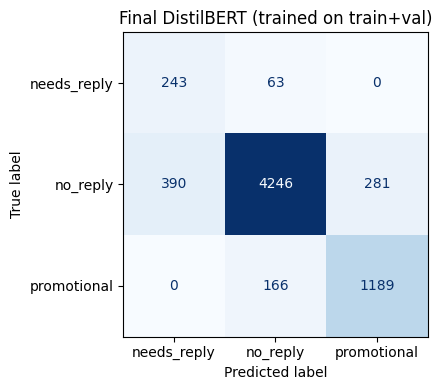

### Sweep best vs final retrain

,Metric,Sweep best (train only),Final (train+val),Delta
0,Accuracy,0.8753,0.8632,-0.0121
1,Macro F1,0.7642,0.7545,-0.0097
2,Weighted F1,0.8818,0.8733,-0.0085
3,needs_reply F1,0.5348,0.5176,-0.0172


In [16]:
# ── Final retrain: DistilBERT on train+val, evaluate on test ──────────

FINAL_SPEC = {
    "display_name": "DistilBERT final (train+val)",
    "checkpoint": "distilbert-base-multilingual-cased",
    "max_length": 512,
    "learning_rate": 5e-5,
    "train_batch_size": 128,
    "eval_batch_size": 256,
    "gradient_accumulation_steps": 1,
    "num_train_epochs": 4,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
}

# Merge train + val
df_train_full = pd.concat([df_train, df_val], ignore_index=True)
train_full_ds = build_dataset(df_train_full)

# Recompute class weights on the larger training set
full_class_counts = df_train_full[LABEL_COLUMN].value_counts().reindex(LABELS)
full_class_weights = torch.tensor(
    len(df_train_full) / (len(LABELS) * full_class_counts.values),
    dtype=torch.float,
)

display(Markdown(
    f"**Final training set:** {len(df_train_full):,} samples "
    f"(was {len(df_train):,} train + {len(df_val):,} val)  ·  "
    f"**Test set:** {len(df_test):,} samples (unchanged)"
))

slug = slugify(FINAL_SPEC["display_name"])
run_dir = OUTPUT_ROOT / slug
best_dir = run_dir / "best_model"
run_dir.mkdir(parents=True, exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(FINAL_SPEC["checkpoint"], use_fast=True)
encoded_train_full = tokenize_split(train_full_ds, tokenizer, FINAL_SPEC["max_length"])
encoded_test = tokenize_split(test_ds, tokenizer, FINAL_SPEC["max_length"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
model = AutoModelForSequenceClassification.from_pretrained(
    FINAL_SPEC["checkpoint"],
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label,
)
if model.config.pad_token_id is None and tokenizer.pad_token_id is not None:
    model.config.pad_token_id = tokenizer.pad_token_id

training_args = TrainingArguments(
    output_dir=str(run_dir),
    learning_rate=FINAL_SPEC["learning_rate"],
    per_device_train_batch_size=FINAL_SPEC["train_batch_size"],
    per_device_eval_batch_size=FINAL_SPEC["eval_batch_size"],
    gradient_accumulation_steps=FINAL_SPEC["gradient_accumulation_steps"],
    num_train_epochs=FINAL_SPEC["num_train_epochs"],
    weight_decay=FINAL_SPEC["weight_decay"],
    warmup_ratio=FINAL_SPEC["warmup_ratio"],
    eval_strategy="no",  # no val set this time
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=1,
    report_to="none",
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
    remove_unused_columns=True,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_train_full,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=full_class_weights,
)

trainer.train()

# ── Evaluate on held-out test set ────────────────────────────────────
test_metrics = trainer.evaluate(encoded_test, metric_key_prefix="test")
predictions = trainer.predict(encoded_test)
pred_ids = np.argmax(predictions.predictions, axis=-1)
true_ids = predictions.label_ids

report_df = pd.DataFrame(
    classification_report(
        true_ids, pred_ids,
        labels=list(range(len(LABELS))),
        target_names=LABELS,
        output_dict=True,
        zero_division=0,
    )
).T.round(4)

# Save artifacts
trainer.save_model(str(best_dir))
tokenizer.save_pretrained(str(best_dir))
report_df.to_csv(run_dir / "classification_report.csv")
save_json(test_metrics, run_dir / "metrics.json")

display(Markdown("## Final model test results (DistilBERT trained on train+val)"))
display(pd.DataFrame([test_metrics]).T.round(4))
display(report_df)

# ── Confusion matrix ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(true_ids, pred_ids, labels=list(range(len(LABELS))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Final DistilBERT (trained on train+val)")
plt.tight_layout()
plt.show()

# ── Compare sweep-best vs final retrain ──────────────────────────────
sweep_best = results_df.iloc[0]  # already sorted by test_macro_f1 desc
compare = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1", "Weighted F1", "needs_reply F1"],
    "Sweep best (train only)": [
        sweep_best["test_accuracy"],
        sweep_best["test_macro_f1"],
        sweep_best["test_weighted_f1"],
        sweep_best["test_f1_needs_reply"],
    ],
    "Final (train+val)": [
        test_metrics["test_accuracy"],
        test_metrics["test_macro_f1"],
        test_metrics["test_weighted_f1"],
        test_metrics["test_f1_needs_reply"],
    ],
}).round(4)
compare["Delta"] = (compare["Final (train+val)"] - compare["Sweep best (train only)"]).round(4)
display(Markdown("### Sweep best vs final retrain"))
display(compare)

del trainer, model, tokenizer, encoded_train_full, encoded_test, predictions
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
